In [12]:
import mne
import pandas as pd
import pyedflib
from copy import deepcopy
from typing import Final

In [13]:
raw = mne.io.read_raw_edf("data/eeg_test.edf", preload=True)
raw_initial = deepcopy(raw)
ecg_like = [ch for ch in raw.ch_names if "ECG" in ch.upper()]
if ecg_like:
    raw.drop_channels(ecg_like)
numpoint: Final[int] = 20000
start_phys = 4000
data = raw.get_data()
data = data[:, start_phys:numpoint]
channel_names = raw.ch_names
df = pd.DataFrame(data.T, columns=raw.ch_names)
df.T.to_csv("data/eeg_test_converted.csv", index=False, header=False)

Extracting EDF parameters from /Users/paks/Polytech/eeg_practice/ArtifactRemovalTransformer/data/eeg_test.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 495499  =      0.000 ...   990.998 secs...


In [14]:
import matplotlib.pyplot as plt
import numpy as np

EEG FP1-A1
EEG FP2-A2
EEG F3-A1
EEG F4-A2
EEG C3-A1
EEG C4-A2
EEG P3-A1
EEG P4-A2
EEG O1-A1
EEG O2-A2
EEG F7-A1
EEG F8-A2
EEG T3-A1
EEG T4-A2
EEG T5-A1
EEG T6-A2
EEG FPZ-A1
EEG FZ-A2
EEG CZ-A1
EEG PZ-A2
EEG OZ-A1


Text(0.5, 1.0, 'Our before')

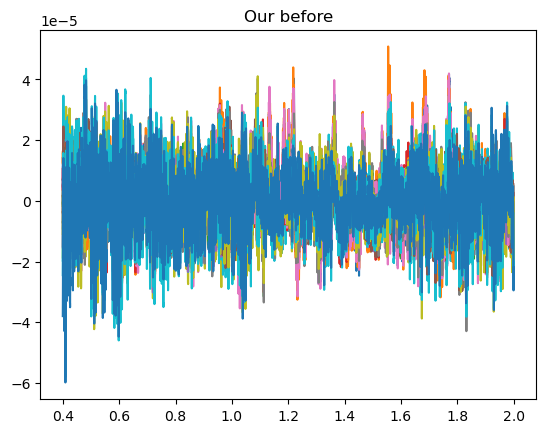

In [15]:
x = np.arange(0.4, 2, 0.0001)

for i in range(len(channel_names)):
    y = data[i]
    plt.plot(x, y)
    print(channel_names[i])
plt.title("Our before")

In [16]:
# print(raw)
# print(raw.info)
# print(raw.ch_names)
eeg_initial_data = raw_initial.get_data()
print(eeg_initial_data.shape)
raw.plot(n_channels = len(raw.ch_names), duration=20.0, start=10.0)

(22, 495500)
Using pyopengl with version 3.1.9


In [17]:
!python main.py

/Users/paks/Polytech/eeg_practice/ArtifactRemovalTransformer/model/tf_model.py:339: UserWarning: nn.init.xavier_uniform is now deprecated in favor of nn.init.xavier_uniform_.
  nn.init.xavier_uniform(p)
Using ART model to reconstruct outputsample-1 has been success in 3.142220973968506 sec(s)
Using ART model to reconstruct outputsample-2 has been success in 3.1207830905914307 sec(s)
Using ART model to reconstruct outputsample-3 has been success in 3.075528860092163 sec(s)


In [18]:
csv_path = 'data/our_output.csv'
edf_path = 'data/our_output.edf'

output = pd.read_csv(csv_path, header=None)
output = output.transpose()

n_channels = output.shape[1]
n_samples = output.shape[0]
sampling_rate = 500

signal_headers = []
for ch in range(n_channels):
    signal_headers.append({
        'label': channel_names[ch],
        'dimension': 'uV',
        'sample_frequency': sampling_rate,
        'physical_min': np.min(output.iloc[:, ch]),
        'physical_max': np.max(output.iloc[:, ch]),
        'digital_min': -32768,
        'digital_max': 32767,
        'transducer': '',
        'prefilter': ''
    })

edf_writer = pyedflib.EdfWriter(edf_path, n_channels=n_channels)
edf_writer.setSignalHeaders(signal_headers)

signals = [output.iloc[:, ch].to_numpy().astype(np.float64) for ch in range(n_channels)]

edf_writer.writeSamples(signals)
edf_writer.close()

print(f"File saved as {edf_path}")


File saved as data/our_output.edf


/Users/paks/micromamba/envs/art/lib/python3.10/site-packages/pyedflib/edfwriter.py:133: UserWarning: Physical minimum for channel 0 (EEG FP1-A1) is -5.915729522705078, which has 18 chars, however, EDF+ can only save 8 chars, will be truncated to -5.91572, some loss of precision is to be expected
  warnings.warn('Physical minimum for channel {} ({}) is {}, which has {} chars, '
/Users/paks/micromamba/envs/art/lib/python3.10/site-packages/pyedflib/edfwriter.py:140: UserWarning: Physical maximum for channel 0 (EEG FP1-A1) is 7.354862213134766, which has 17 chars, however, EDF+ can only save 8 chars, will be truncated to 7.354862, some loss of precision is to be expected.
  warnings.warn('Physical maximum for channel {} ({}) is {}, which has {} chars, '
/Users/paks/micromamba/envs/art/lib/python3.10/site-packages/pyedflib/edfwriter.py:133: UserWarning: Physical minimum for channel 1 (EEG FP2-A2) is -5.933183670043945, which has 18 chars, however, EDF+ can only save 8 chars, will be truncat

In [20]:
raw_after = mne.io.read_raw_edf("data/our_output.edf", preload=True)
numpoint: Final[int] = 20000
start_phys = 4000
data_after = raw_after.get_data()
data_after = data_after[:, start_phys:numpoint]
channel_names_after = raw_after.ch_names

eeg_after_data = raw_after.get_data()
print(eeg_after_data.shape)
raw_after.plot(n_channels = len(raw_after.ch_names), duration=20.0, start=10.0)

Extracting EDF parameters from /Users/paks/Polytech/eeg_practice/ArtifactRemovalTransformer/data/our_output.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 15499  =      0.000 ...    30.998 secs...
(21, 15500)
Using pyopengl with version 3.1.9


Channels marked as bad:
none


In [40]:
def plot_art(start: float, end: float, raw_initial: mne.io.Raw, raw_after: mne.io.Raw) -> None:
    sfreq = raw_initial.info["sfreq"]
    start_sample = int(start * sfreq)
    stop_sample = int(end * sfreq)


    channel_names = raw_initial.ch_names
    n_channels = len(channel_names)


    data_initial = raw_initial.copy().pick("eeg").get_data(start=start_sample, stop=stop_sample)
    data_after = raw_after.copy().pick("eeg").get_data(start=start_sample, stop=stop_sample)

    times = raw_initial.times[start_sample:stop_sample]


    fig, axes = plt.subplots(n_channels, 2, figsize=(12, n_channels * 1.5), sharex=True)


    if n_channels == 1:
        axes = axes.reshape(1, 2)
        fig.suptitle(f"Сигналы ЭЭГ: до и после ART ({start:.1f}–{end:.1f} сек)", fontsize=16)

    for i in range(n_channels):
        # before
        axes[i, 0].plot(times, data_initial[i], color='blue')
        axes[i, 0].set_ylabel(channel_names[i], fontsize=9)
        axes[i, 0].tick_params(axis='y', labelsize=8)
        if i == 0:
            axes[i, 0].set_title("До ART", fontsize=12)

        # after
        axes[i, 1].plot(times, data_after[i], color='green')
        if i == 0:
            axes[i, 1].set_title("После ART", fontsize=12)

        if i != n_channels - 1:
            axes[i, 0].tick_params(labelbottom=False)
            axes[i, 1].tick_params(labelbottom=False)
        else:
            axes[i, 0].set_xlabel("Время (с)")
            axes[i, 1].set_xlabel("Время (с)")

    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()

IndexError: index 21 is out of bounds for axis 0 with size 21

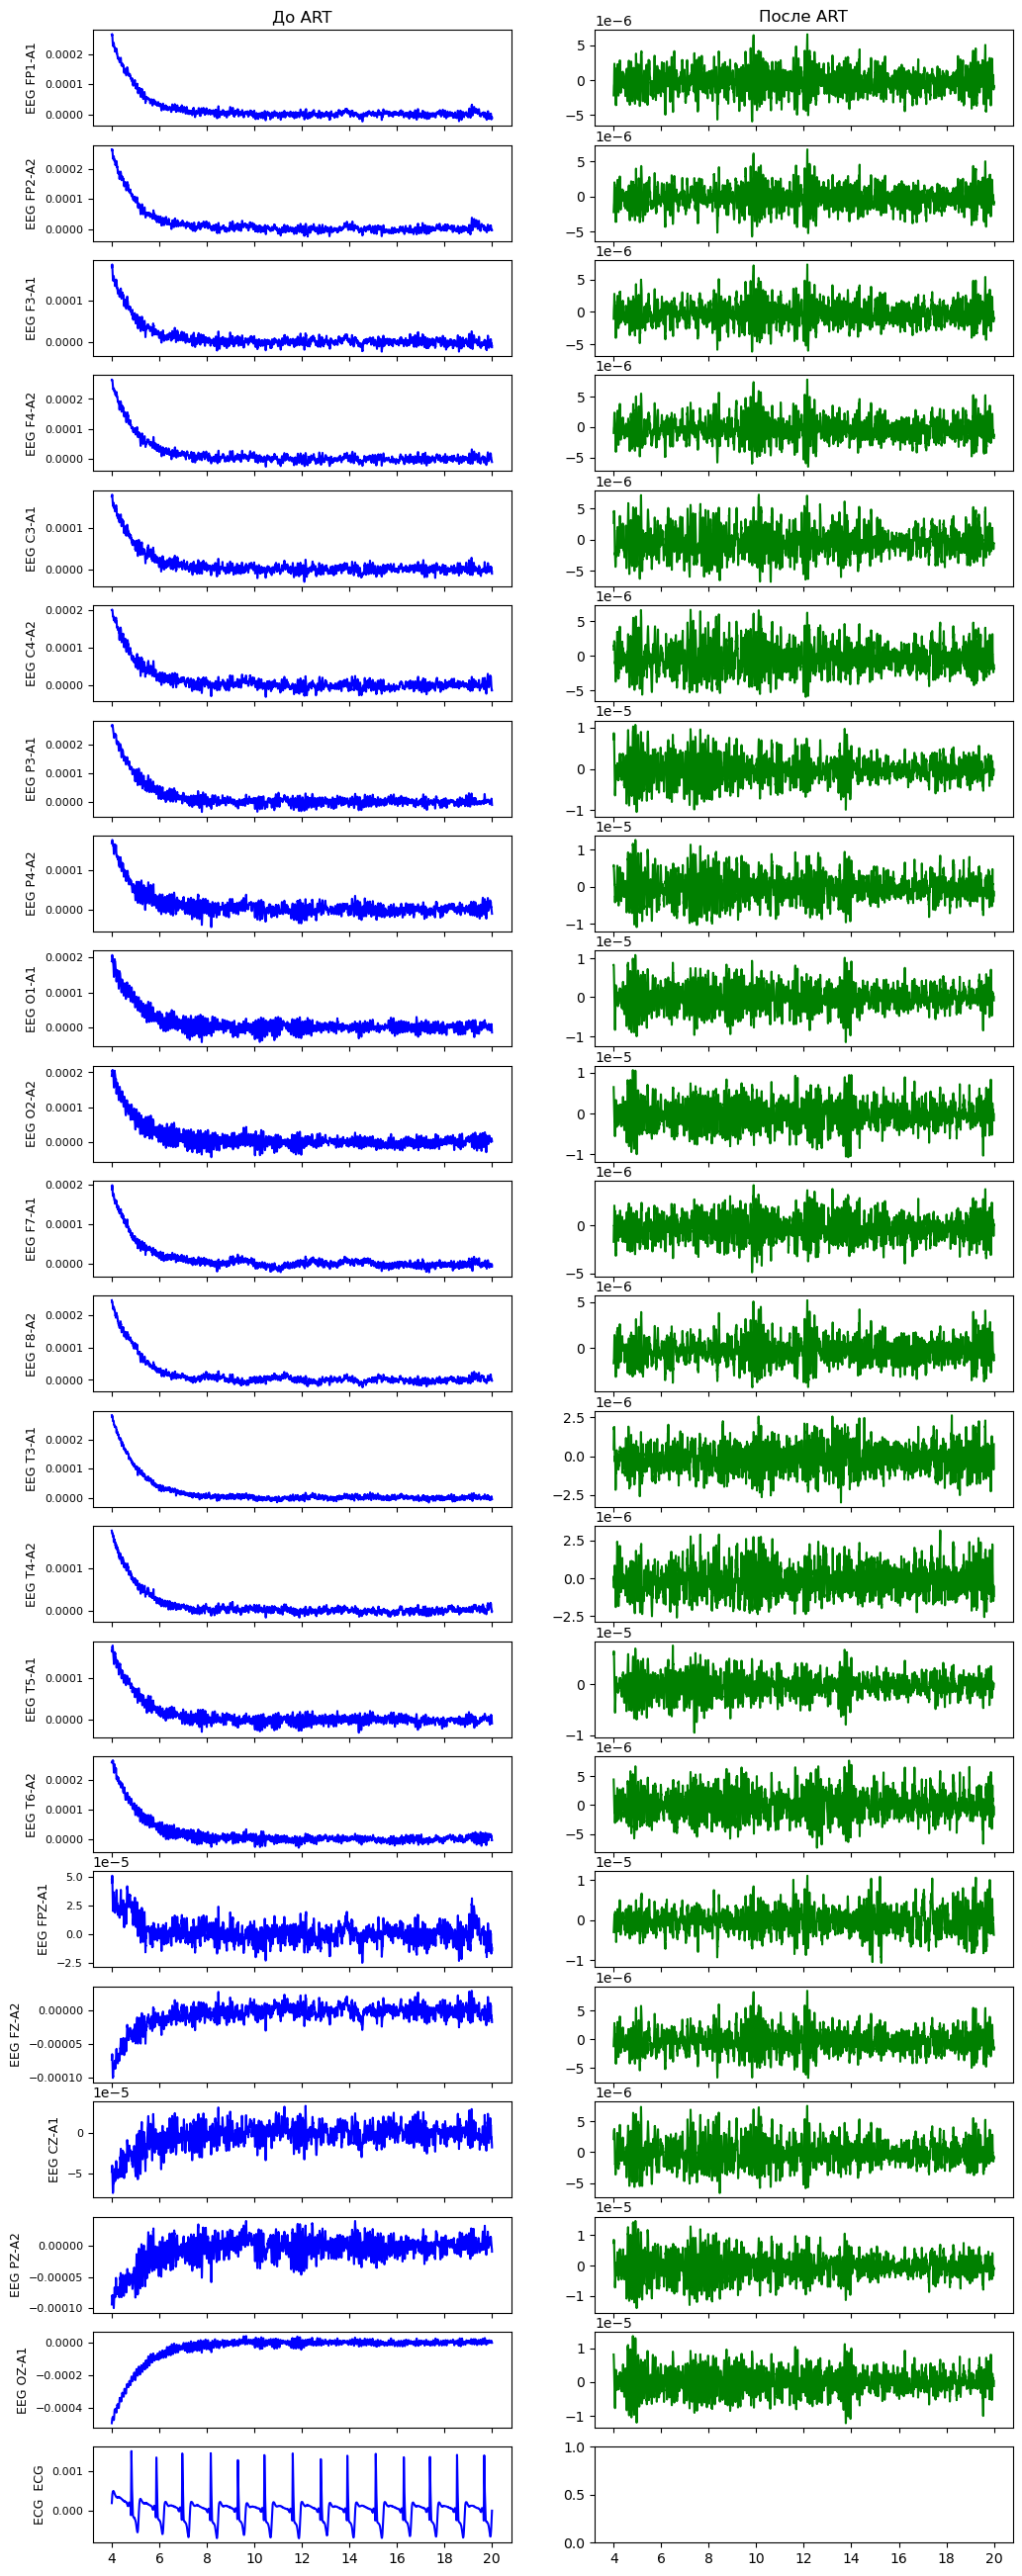

In [42]:
plot_art(4.0, 20.0, raw_initial, raw_after)